# Life Cycle Assessment of Buildings with Brightway and Ecoinvent

## Computing Environmental Burdens

First, we again load the necessary Brightway Python libraries.

In [1]:
import bw2data as bd
import bw2io as bi
import bw2calc as bc

/Users/michaelweinold/venv/bw25/lib/python3.12/site-packages/bw2calc/__init__.py:50: UserWarning: 
It seems like you have an ARM architecture, but haven't installed scikit-umfpack:

    https://pypi.org/project/scikit-umfpack/

Installing it could give you much faster calculations.

  warnings.warn(UMFPACK_WARNING)


In [ ]:
bd.projects

Now, we can check if the Ecoinvent database is available:

In [ ]:
bd.databases

We bind the Ecoinvent database to a variable `ei` for easier access:

In [7]:
ei = bd.Database("ecoinvent-3.10-cutoff")

We can define our _foreground database_, in an Excel file.  
The template file contains three simple processes: 

1. `house construction`
2. `concrete operation`
3. `house demolition`

These processes are linked to some processes from the Ecoinvent database.  
For example, the `house construction` process uses:

1. `market for concrete, 30MPa`
2.  `diesel, burned in building machine`

💻 You can search for Ecoinvent processes using [the EcoQuery search engine](https://ecoquery.ecoinvent.org/3.10/cutoff).  
📖 The following commands are [explained in the _Learn Brightway_ online eBook](https://learn.brightway.dev/en/latest/content/chapters/BW25/BW25_introduction.html#importing-a-foreground-dataset-from-excel).

In [29]:
importer = bi.ExcelImporter("life_cycle_inventory.xlsx")
importer.apply_strategies()
importer.match_database(fields=["name", "unit", "reference product", "location"])
importer.match_database(
    "ecoinvent-3.10-cutoff", fields=["name", "unit", "location", "reference product"]
)
importer.match_database("ecoinvent-3.10-biosphere", fields=["name", "categories", "location"])

Extracted 3 worksheets in 0.02 seconds
Applying strategy: csv_restore_tuples
Applying strategy: csv_restore_booleans
Applying strategy: csv_numerize
Applying strategy: csv_drop_unknown
Applying strategy: csv_add_missing_exchanges_section
Applying strategy: normalize_units
Applying strategy: normalize_biosphere_categories
Applying strategy: normalize_biosphere_names
Applying strategy: strip_biosphere_exc_locations
Applying strategy: set_code_by_activity_hash
Applying strategy: link_iterable_by_fields
Applying strategy: assign_only_product_as_production
Applying strategy: link_technosphere_by_activity_hash
Applying strategy: drop_falsey_uncertainty_fields_but_keep_zeros
Applying strategy: convert_uncertainty_types_to_integers
Applying strategy: convert_activity_parameters_to_list
Applied 16 strategies in 0.08 seconds
Applying strategy: link_iterable_by_fields
Applying strategy: link_iterable_by_fields
Applying strategy: link_iterable_by_fields


This should have added the three processes to a new Brightway database called `Construction Database`.  
It should include 3 individual processes (=graph nodes). Let's check that:

In [30]:
importer.statistics()

Graph statistics for `Construction Database` importer:
3 graph nodes:
	process: 3
5 graph edges:
	technosphere: 5
5 edges to the following databases:
	ecoinvent-3.10-cutoff: 5
0 unique unlinked edges (0 total):




(3, 5, 0, 0)

If we made any mistakes in the naming of the processes, the associated reference product or units, we can check this by listing _unlinked exchanges_:

In [31]:
list(importer.unlinked)

[]

If there are no unlinked exchanges, we can proceed to write the database to disk:

In [32]:
importer.write_database()

100%|██████████| 3/3 [00:00<00:00, 5660.33it/s]

14:14:00+0200 [info     ] Vacuuming database            


Created database: Construction Database


Now, it will show up in the list of available databases: 🧞‍♂️

In [33]:
bd.databases

Databases dictionary with 3 object(s):
	Construction Database
	ecoinvent-3.10-biosphere
	ecoinvent-3.10-cutoff

📖 You can look for Brightway commands in [the _Cheat Sheet_ section of the online documentation](https://docs.brightway.dev/en/latest/content/cheatsheet/index.html).

We bind the construction to a variable `db_construction` for easier access:

In [34]:
db_construction = bd.Database("Construction Database")

To get a random process from the database, we can use:

In [35]:
act_random = db_construction.random()

To list all metadata of the process, we can use:

In [36]:
act_random.as_dict()

{'code': 'house_demolition',
 'location': 'AT',
 'amount': 1,
 'type': 'processwithreferenceproduct',
 'unit': 'unit',
 'reference product': 'house',
 'name': 'house demolition',
 'worksheet name': 'house demolition',
 'database': 'Construction Database',
 'id': 224502809250304002}

Now, we can compute the environmental burdens of the building operation.  
First, we select an impact assessment method. We can list them all with:

In [37]:
bd.methods

Methods dictionary with 668 objects, including:
	('ecoinvent-3.10', 'CML v4.8 2016', 'acidification', 'acidification (incl. fate, average Europe total, A&B)')
	('ecoinvent-3.10', 'CML v4.8 2016', 'climate change', 'global warming potential (GWP100)')
	('ecoinvent-3.10', 'CML v4.8 2016', 'ecotoxicity: freshwater', 'freshwater aquatic ecotoxicity (FAETP inf)')
	('ecoinvent-3.10', 'CML v4.8 2016', 'ecotoxicity: marine', 'marine aquatic ecotoxicity (MAETP inf)')
	('ecoinvent-3.10', 'CML v4.8 2016', 'ecotoxicity: terrestrial', 'terrestrial ecotoxicity (TETP inf)')
	('ecoinvent-3.10', 'CML v4.8 2016', 'energy resources: non-renewable', 'abiotic depletion potential (ADP): fossil fuels')
	('ecoinvent-3.10', 'CML v4.8 2016', 'eutrophication', 'eutrophication (fate not incl.)')
	('ecoinvent-3.10', 'CML v4.8 2016', 'human toxicity', 'human toxicity (HTP inf)')
	('ecoinvent-3.10', 'CML v4.8 2016', 'material resources: metals/minerals', 'abiotic depletion potential (ADP): elements (ultimate reserve

These are [Python tuples](https://docs.python.org/3/tutorial/datastructures.html#tuples-and-sequences). For now, we select the Global Warming Potential (GWP) method:

In [38]:
method_gwp = ('ecoinvent-3.10', 'CML v4.8 2016', 'climate change', 'global warming potential (GWP100)')

Second, we select the _functional unit_ of the assessment:

In [39]:
house_construction = bd.get_node(
    name="house construction",
    database="Construction Database"
)

Now, we can [set up the calculation](https://docs.brightway.dev/en/latest/content/cheatsheet/lca.html#single-functional-unit-and-lcia-set):

In [40]:
functional_unit, data_objs, _ = bd.prepare_lca_inputs(
    demand={house_construction: 1},
    method=method_gwp
)

...and run it:

In [41]:
lca = bc.LCA(demand=functional_unit, data_objs=data_objs)
lca.lci()
lca.lcia()

This was your first real life cycle assessment calculation! We can view the results:

In [42]:
lca.score

7291.5078429120495

We can also check the contributions of individual processes to the overall result:

In [43]:
lca.to_dataframe()

,row_index,col_index,amount,row_id,col_id,row_database,row_code,row_name,row_location,row_unit,row_type,row_categories,row_product,col_database,col_code,col_name,col_location,col_unit,col_type,col_reference_product
0,718,13679,4671.479965,202346863644446745,202347026903535616,ecoinvent-3.10-biosphere,349b29d1-3e58-4c66-98b9-9d1a076efd2e,"Carbon dioxide, fossil",None,kilogram,emission,air,None,ecoinvent-3.10-cutoff,e93cfaabe77e063ac14bfba7d3d4145f,clinker production,CH,kilogram,processwithreferenceproduct,clinker
1,718,8478,1466.565763,202346863644446745,202347001452498945,ecoinvent-3.10-biosphere,349b29d1-3e58-4c66-98b9-9d1a076efd2e,"Carbon dioxide, fossil",None,kilogram,emission,air,None,ecoinvent-3.10-cutoff,b296455bcee6a84b80bca90ed02300da,"diesel, burned in building machine",GLO,megajoule,processwithreferenceproduct,"diesel, burned in building machine"
2,894,12758,200.135619,202346863673806851,202347022201720834,ecoinvent-3.10-biosphere,70ef743b-3ed5-4a6d-b192-fb6d62378555,"Methane, fossil",None,kilogram,emission,air::non-urban air or from high stacks,None,ecoinvent-3.10-cutoff,78ec33cb6f6542829eb39977781e9e5d,natural gas venting from petroleum/natural gas...,GLO,cubic meter,processwithreferenceproduct,"natural gas, vented"
3,718,19858,68.935284,202346863644446745,202347059610718208,ecoinvent-3.10-biosphere,349b29d1-3e58-4c66-98b9-9d1a076efd2e,"Carbon dioxide, fossil",None,kilogram,emission,air,None,ecoinvent-3.10-cutoff,4971ae3c9a017f22f018cd4ef9439186,"diesel production, petroleum refinery operation",RoW,kilogram,processwithreferenceproduct,diesel
4,716,1419,59.433222,202346863644446742,202346965503119360,ecoinvent-3.10-biosphere,aa7cac3a-3625-41d4-bc54-33e2cf11ec46,"Carbon dioxide, fossil",None,kilogram,emission,air::non-urban air or from high stacks,None,ecoinvent-3.10-cutoff,54eebb408bca82913a19e19ecd8a3eb9,"sweet gas, burned in gas turbine",GLO,megajoule,processwithreferenceproduct,"sweet gas, burned in gas turbine"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,716,18290,0.572829,202346863644446742,202347051406659584,ecoinvent-3.10-biosphere,aa7cac3a-3625-41d4-bc54-33e2cf11ec46,"Carbon dioxide, fossil",None,kilogram,emission,air::non-urban air or from high stacks,None,ecoinvent-3.10-cutoff,5fecc6edf3f590f6efe0bb71bd0697f0,"electricity production, lignite",US-SERC,kilowatt hour,processwithreferenceproduct,"electricity, high voltage"
196,716,8374,0.568163,202346863644446742,202347000936599552,ecoinvent-3.10-biosphere,aa7cac3a-3625-41d4-bc54-33e2cf11ec46,"Carbon dioxide, fossil",None,kilogram,emission,air::non-urban air or from high stacks,None,ecoinvent-3.10-cutoff,8440532fe33825e23d7e46e16724f217,"electricity production, hard coal",IN-GJ,kilowatt hour,processwithreferenceproduct,"electricity, high voltage"
197,80,14787,0.562597,202346863556366395,202347032557457408,ecoinvent-3.10-biosphere,f9749677-9c9f-4678-ab55-c607dfdc2cb9,"Carbon dioxide, fossil",None,kilogram,emission,air::urban air close to ground,None,ecoinvent-3.10-cutoff,cbee0a33e3ab4b3730ae3a8a3af0668c,"treatment of waste mineral oil, hazardous wast...",CH,kilogram,processwithreferenceproduct,waste mineral oil
198,80,12548,0.562597,202346863556366395,202347021081841664,ecoinvent-3.10-biosphere,f9749677-9c9f-4678-ab55-c607dfdc2cb9,"Carbon dioxide, fossil",None,kilogram,emission,air::urban air close to ground,None,ecoinvent-3.10-cutoff,514dd8cad521548d421bf33bcd8d91af,"treatment of waste mineral oil, hazardous wast...",CH,kilogram,processwithreferenceproduct,waste mineral oil


## Basic Visualization of Results

In [44]:
from matplotlib import pyplot as plt

We can now compare the impacts of the three life cycle stages:

In [45]:
functional_unit, data_objs, _ = bd.prepare_lca_inputs(
    demand={bd.get_node(name="house construction", database="Construction Database"): 1},
    method=method_gwp
)
lca = bc.LCA(demand=functional_unit, data_objs=data_objs)
lca.lci()
lca.lcia()
impact_construction = lca.score

In [46]:
functional_unit, data_objs, _ = bd.prepare_lca_inputs(
    demand={bd.get_node(name="house operation", database="Construction Database"): 1},
    method=method_gwp
)
lca = bc.LCA(demand=functional_unit, data_objs=data_objs)
lca.lci()
lca.lcia()
impact_operation = lca.score

In [47]:
functional_unit, data_objs, _ = bd.prepare_lca_inputs(
    demand={bd.get_node(name="house demolition", database="Construction Database"): 1},
    method=method_gwp
)
lca = bc.LCA(demand=functional_unit, data_objs=data_objs)
lca.lci()
lca.lcia()
impact_demolition = lca.score

Text(0, 0.5, 'GWP(100) [kg CO2-eq]')

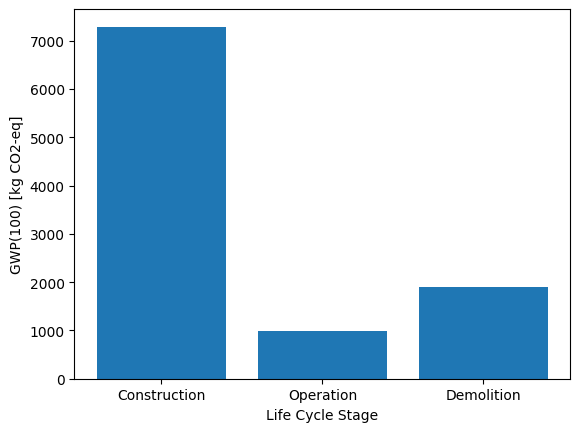

In [48]:
categories = ['Construction', 'Operation', 'Demolition']
values = [impact_construction, impact_operation, impact_demolition]

plt.bar(categories, values)

plt.xlabel('Life Cycle Stage')
plt.ylabel('GWP(100) [kg CO2-eq]')

Aha - but operating the house for only one year is not very realistic. Let's assume a lifespan of 50 years. Have fun adapting the code!